In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML
import time

df = pd.read_csv("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/benchmarking_results/all_hyperparameter_test_results.csv")
df.head()

,sample_type,sample_name,kernel_size,d_model,d_ff,num_layers,num_heads,batch_size,epochs,bias_scale,...,peak_allocated_mb,peak_reserved_mb,allocated_mb,reserved_mb,free_mb,total_memory_mb,allocated_pct_total,reserved_pct_total,free_pct_total,replicate
0,Macrophage,buffer_3,128,128,512,3,4,64,200,0.0,...,1545.631348,3076.0,59.837737,3075.699881,29018.550893,32494.125,0.184149,9.465403,89.303992,1
1,Macrophage,buffer_3,64,128,512,3,4,64,200,0.0,...,1945.115723,4440.0,59.814299,4439.052143,27655.197976,32494.125,0.184077,13.661091,85.108302,1
2,Macrophage,buffer_3,128,192,768,3,4,64,200,0.0,...,2146.129395,7312.0,87.324065,7310.659524,24783.590476,32494.125,0.268738,22.498404,76.270989,1
3,Macrophage,buffer_3,64,192,768,3,4,64,200,0.0,...,2574.268066,6238.0,87.300627,6237.576786,25856.673214,32494.125,0.268666,19.196014,79.573379,1
4,Macrophage,buffer_3,128,128,512,3,8,64,200,0.0,...,1865.487793,7590.0,59.837737,7590.000000,24504.250000,32494.125,0.184149,23.358069,75.411324,1


In [6]:
id_cols = ['sample_type', 'sample_name']
hyperparam_cols = [
    'kernel_size', 
    'd_model', 
    'd_ff',
    'num_layers', 
    'num_heads', 
    'batch_size', 
    'epochs', 
    'bias_scale',
    'grad_attrib_batches', 
    'grad_attrib_tgs_per_batch',
    'dataloader_workers', 
    'max_cached', 
    'norm_target_sum', 
    'min_rna_disp',
    'min_atac_disp', 
    'rna_pcs', 
    'rna_neighbors', 
    'atac_pcs',
    'atac_neighbors', 
    'min_atac_hvg_mean', 
    'max_atac_hvg_mean',
    'filter_rna_hvgs', 
    'filter_atac_hvgs', 
    'tf_list_file',
    'promoter_upstream', 
    'promoter_downstream', 
    'distal_max', 
    'n_tss',
    'extend_upstream', 
    'extend_downstream', 
    'hops'
    ]
target_cols = ['pooled_median_auroc', 'per_tf_median_auroc', 'r2_unscaled', 'r2_scaled']

for col in hyperparam_cols + target_cols:
    if col in df.columns and df[col].dtype == object:
        try:
            df[col] = pd.to_numeric(df[col])
        except Exception:
            pass

global_var_cols = ['kernel_size', 'd_model', 'num_heads', 'hops']

print("Globally varying hyperparameters:")
print(global_var_cols)

per_sample_var_df = (
    df.groupby(id_cols)[hyperparam_cols]
      .nunique(dropna=False)
      .reset_index()
)

per_sample_var_map = {}
for _, row in per_sample_var_df.iterrows():
    key = (row['sample_type'], row['sample_name'])
    var_cols_this_sample = [c for c in hyperparam_cols if row[c] > 1]
    per_sample_var_map[key] = var_cols_this_sample

print("\nVarying hyperparameters by sample:")
for key, vals in per_sample_var_map.items():
    print(f"{key}: {vals}")

Globally varying hyperparameters:
['kernel_size', 'd_model', 'num_heads', 'hops']

Varying hyperparameters by sample:
('K562', 'sample_1'): ['kernel_size', 'd_model', 'd_ff', 'num_heads', 'batch_size', 'epochs', 'bias_scale', 'min_rna_disp', 'min_atac_disp', 'rna_pcs', 'rna_neighbors', 'atac_pcs', 'atac_neighbors', 'filter_rna_hvgs', 'filter_atac_hvgs', 'hops']
('Macrophage', 'buffer_1'): ['kernel_size', 'd_model', 'd_ff', 'num_heads', 'batch_size', 'epochs', 'bias_scale', 'min_rna_disp', 'min_atac_disp', 'hops']
('Macrophage', 'buffer_2'): ['kernel_size', 'd_model', 'd_ff', 'num_heads', 'batch_size', 'epochs', 'bias_scale', 'min_rna_disp', 'min_atac_disp', 'hops']
('Macrophage', 'buffer_3'): ['kernel_size', 'd_model', 'd_ff', 'num_heads', 'batch_size', 'epochs', 'bias_scale', 'min_rna_disp', 'min_atac_disp', 'hops']
('Macrophage', 'buffer_4'): ['kernel_size', 'd_model', 'd_ff', 'num_heads', 'batch_size', 'epochs', 'bias_scale', 'min_rna_disp', 'min_atac_disp', 'hops']
('iPSC', 'WT_D13

## Hyperparameter effect boxplots by sample

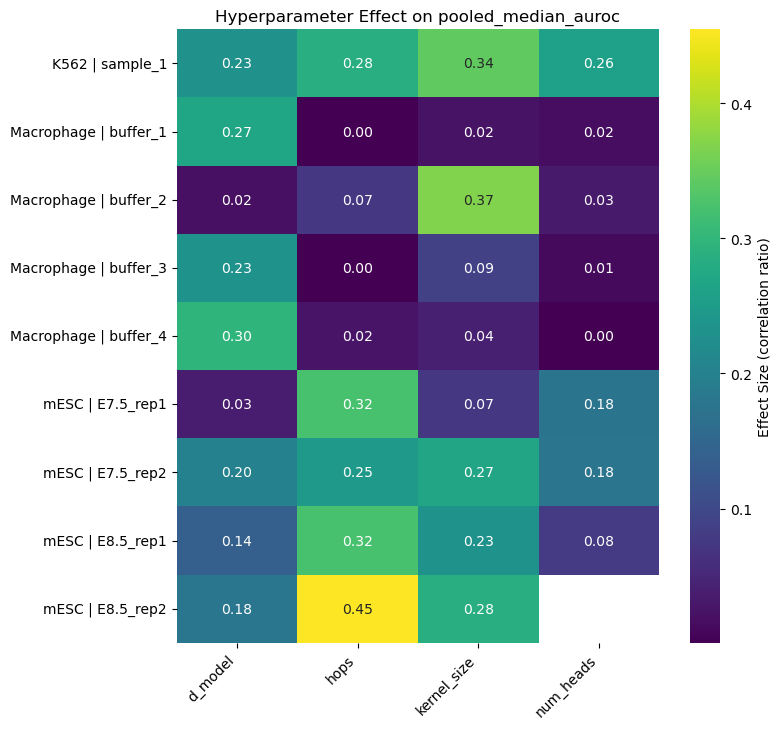

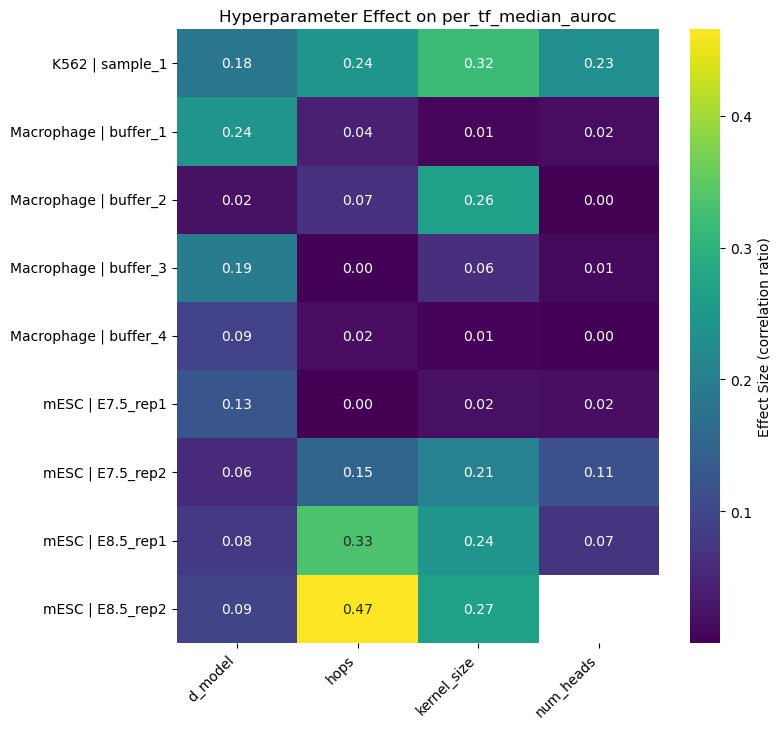

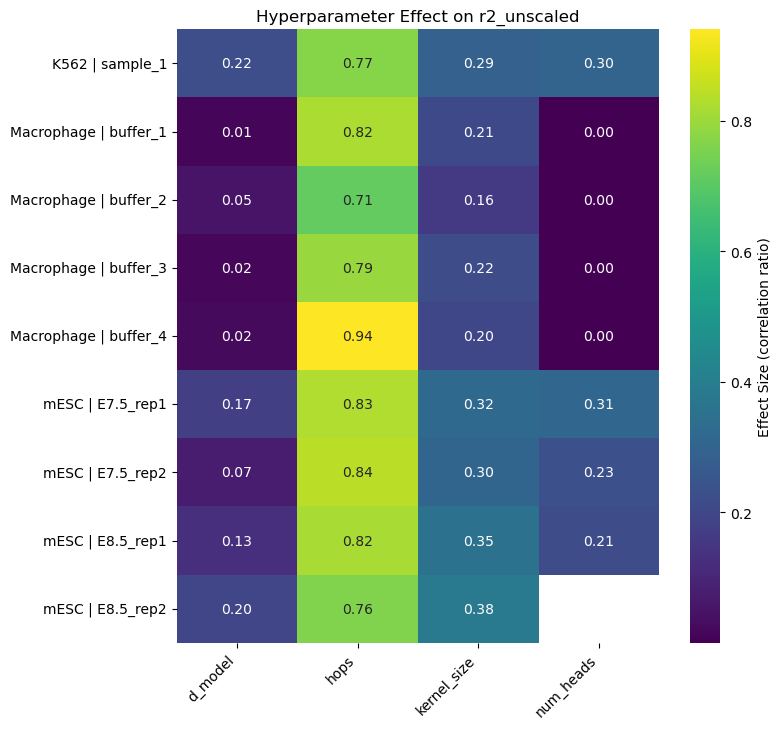

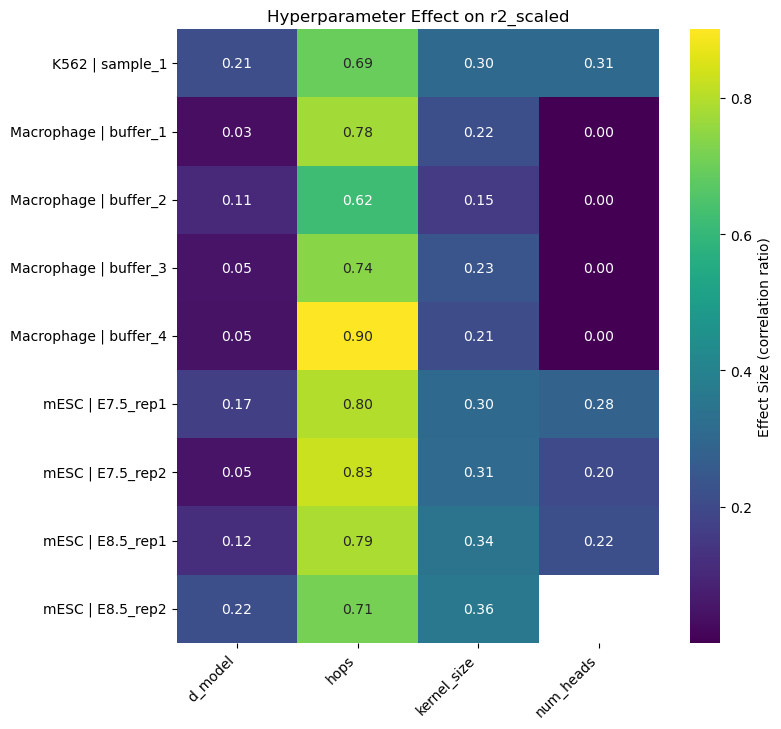

In [7]:
def correlation_ratio(categories, measurements):
    fcat, _ = pd.factorize(categories)
    cat_num = np.max(fcat) + 1
    y_avg_array = np.zeros(cat_num)
    n_array = np.zeros(cat_num)

    for i in range(cat_num):
        cat_measures = measurements[np.argwhere(fcat == i).flatten()]
        n_array[i] = len(cat_measures)
        y_avg_array[i] = np.average(cat_measures)

    y_total_avg = np.sum(y_avg_array * n_array) / np.sum(n_array)
    numerator = np.sum(n_array * np.power(y_avg_array - y_total_avg, 2))
    denominator = np.sum(np.power(measurements - y_total_avg, 2))

    if denominator == 0 or numerator == 0:
        eta = 0.0
    else:
        eta = numerator / denominator

    return eta


# -------------------------
# Effect size function using correlation_ratio
# -------------------------
def correlation_ratio_effect(data, group_col, target_col):
    tmp = data[[group_col, target_col]].dropna()

    if tmp[group_col].nunique() < 2:
        return np.nan

    categories = tmp[group_col].to_numpy()
    measurements = pd.to_numeric(tmp[target_col], errors="coerce").to_numpy()

    valid = ~np.isnan(measurements)
    categories = categories[valid]
    measurements = measurements[valid]

    if len(measurements) == 0:
        return np.nan

    return correlation_ratio(categories, measurements)


# -------------------------
# Compute effect sizes
# -------------------------
rows = []

for (sample_type, sample_name), subdf in df.groupby(id_cols):
    if sample_type != "iPSC":
        sample_id = f"{sample_type} | {sample_name}"

        for var in global_var_cols:
            for target in target_cols:
                val = correlation_ratio_effect(subdf, var, target)

                rows.append({
                    "sample": sample_id,
                    "hyperparameter": var,
                    "target": target,
                    "eta_squared": val
                })

effect_df = pd.DataFrame(rows)


# -------------------------
# Plot heatmaps
# -------------------------
output_dir = Path("./hyperparam_effect_heatmaps")
output_dir.mkdir(parents=False, exist_ok=True)

for target in target_cols:
    plot_df = effect_df[effect_df["target"] == target]

    pivot = plot_df.pivot(
        index="sample",
        columns="hyperparameter",
        values="eta_squared"
    )

    plt.figure(figsize=(2 * pivot.shape[1], 0.6 * len(pivot) + 2))

    sns.heatmap(
        pivot,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        cbar_kws={"label": "Effect Size (correlation ratio)"}
    )

    plt.title(f"Hyperparameter Effect on {target}")
    plt.xlabel("")
    plt.ylabel("")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig(output_dir / f"{target}_per_sample_hyperparameter_effect_heatmap.png", dpi=200, bbox_inches="tight")
    plt.show()

In [8]:

# -------------------------
# Output directory
# -------------------------
out_dir = Path("boxplots_by_celltype")
out_dir.mkdir(exist_ok=True)


In [9]:
for var in global_var_cols:

    plot_df = df.melt(
        id_vars=['sample_type', var],
        value_vars=target_cols,
        var_name='target',
        value_name='value'
    )

    if df[var].nunique() < 2:
        continue

    g = sns.catplot(
        data=plot_df,
        x=var,
        y='value',
        row='sample_type',
        col='target',
        kind='box',
        height=3.5,
        aspect=1.2,
        sharey=False
    )

    # -------------------------
    # Remove default axis labels
    # -------------------------
    # g.set_axis_labels("", "")
    g.set_titles("")

    # -------------------------
    # Set row labels (left side)
    # -------------------------
    for ax, row_name in zip(g.axes[:, 0], g.row_names):
        ax.set_ylabel(row_name, rotation=0, ha='right', va='center', fontsize=18)
        ax.yaxis.set_label_coords(-0.5, 0.5)  # push label left

    # -------------------------
    # Set column labels (bottom)
    # -------------------------
    for ax, col_name in zip(g.axes[0, :], g.col_names):
        ax.set_title(col_name, fontsize=18)


    # -------------------------
    # Title + layout
    # -------------------------
    g.fig.subplots_adjust(top=0.90, left=0.25)
    g.fig.suptitle(f"Effect of {var} across targets (by cell type)")

    plt.savefig(out_dir / f"{var}_facet_by_sampletype.png", dpi=200, bbox_inches='tight')
    plt.close()

In [10]:
def plot_value_by_celltype_boxplots(df: pd.DataFrame, target_col, ylim=(0.1, 0.7)):
    df = df.copy()
    df["sample_type"] = df["sample_type"].astype(str)
    df = df[df["sample_type"] != "iPSC"]
    
    plot_df = df.melt(
        id_vars=["sample_type", target_col],
        value_vars=global_var_cols,
        var_name="variable",
        value_name="value"
    ).dropna(subset=[target_col, "value"]).copy()

    plot_df["value_str"] = plot_df["value"].astype(int).astype(str)

    var_order_map = {}
    for var in global_var_cols:
        vals = df[var].dropna().unique().tolist()
        try:
            vals = sorted(vals)
        except Exception:
            vals = sorted([str(v) for v in vals])
        var_order_map[var] = [str(v) for v in vals]

    g = sns.catplot(
        data=plot_df,
        x="value_str",
        y=target_col,
        row="sample_type",
        col="variable",
        kind="box",
        sharey=True,
        sharex=False,
        height=3.0,
        aspect=1.00,
        margin_titles=True,
        fliersize=0,
        linewidth=2,
        color="#4195DF"
    )

    g.set_titles(row_template="", col_template="")

    for ax, row_name in zip(g.axes[:, 0], g.row_names):
        ax.set_ylabel(row_name, rotation=0, ha="right", va="center", fontsize=24)
        ax.yaxis.set_label_coords(-0.4, 0.5)

    for j, col_name in enumerate(g.col_names):
        bottom_ax = g.axes[-1, j]
        bottom_ax.set_xlabel(col_name, fontsize=24, labelpad=20)

    # remove xlabels from every row except the bottom row
    for i in range(len(g.row_names) - 1):
        for j in range(len(g.col_names)):
            g.axes[i, j].set_xlabel("")

    for i in range(len(g.row_names)):
        for j in range(1, len(g.col_names)):
            g.axes[i, j].set_ylabel("")

    for ax in g.axes.flat:
        # ax.set_title(ax.get_title(), fontsize=22)
        ax.grid(False)

    # Force the figure to finish drawing first
    g.figure.canvas.draw()

    # Then set y-limits on every axis and lock them
    for ax in g.axes.flat:
        ax.set_ylim(ylim[0], ylim[1])
        ax.autoscale(enable=False, axis="y")
        for spine in ax.spines.values():
            spine.set_visible(True)

    # Optional: make them a bit thicker/cleaner
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_linewidth(1.2)

    plt.subplots_adjust(top=0.88, left=0.15, wspace=0.33, hspace=0.35)
    plt.suptitle(f"Effect of hyperparameters on {target_col} by cell type", y=0.95, fontsize=24)

    out_dir = Path("boxplots_by_celltype")
    out_dir.mkdir(exist_ok=True)

    # Use a unique filename to avoid cache issues
    out_file = out_dir / f"{target_col}_by_celltype_all_variables.png"

    plt.savefig(out_file, dpi=200, bbox_inches="tight")
    plt.close()

    return out_file

target_col = target_cols[3]
out_file = plot_value_by_celltype_boxplots(df, target_col, ylim=(0.1, 0.8))

HTML(f'<img src="{out_file}?t={int(time.time())}" height="750">')

In [11]:
df["r2_unscaled"].describe()

count    435.000000
mean       0.595175
std        0.167318
min        0.231987
25%        0.447745
50%        0.625101
75%        0.723583
max        0.881340
Name: r2_unscaled, dtype: float64


=== TOP RUNS: K562 ===
n_rows   : 93
train R² : 0.765


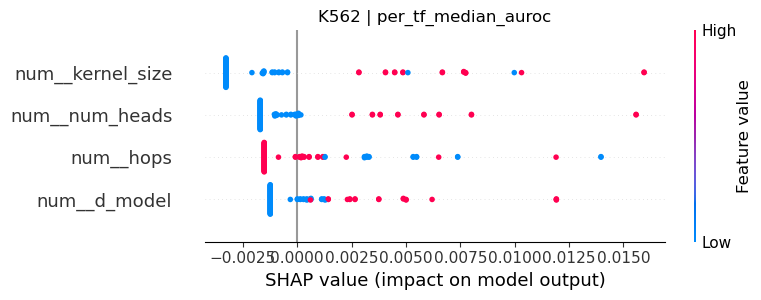


=== TOP RUNS: Macrophage ===
n_rows   : 181
train R² : 0.157


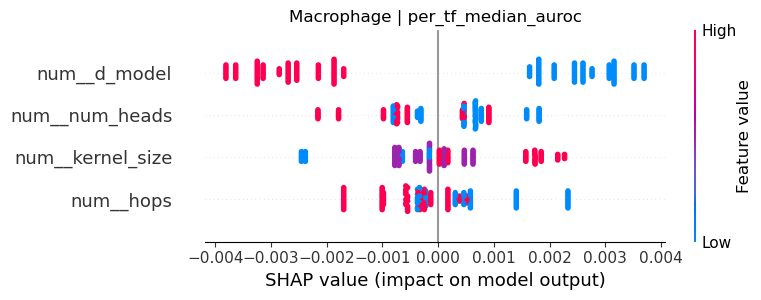


=== TOP RUNS: mESC ===
n_rows   : 148
train R² : 0.399


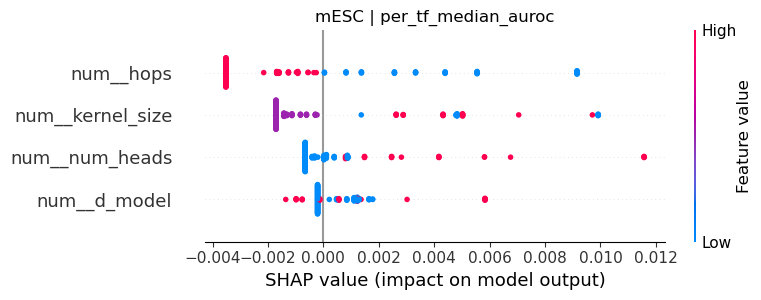

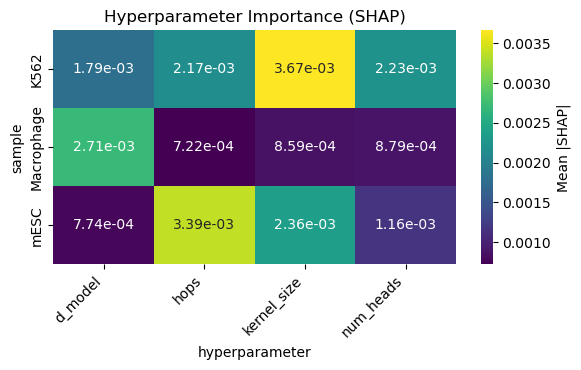

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

import shap


def compute_rf_shap(
    df,
    feature_cols,
    target_col,
    top_quantile=None,
    n_estimators=300,
    random_state=42,
):
    df = df.copy()

    # -------------------------
    # Optional: restrict to top-performing runs
    # -------------------------
    if top_quantile is not None:
        cutoff = df[target_col].quantile(top_quantile)
        df = df[df[target_col] >= cutoff].copy()

    # -------------------------
    # Drop NA
    # -------------------------
    df = df[feature_cols + [target_col]].dropna().copy()

    if len(df) < 5:
        return None

    X = df[feature_cols].copy()
    y = df[target_col].copy()

    # Treat low-cardinality / object columns as categorical
    categorical_cols = [
        c for c in feature_cols
        if X[c].dtype == "object" or str(X[c].dtype).startswith("category")
    ]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    # You can force integer hyperparameters to categorical if desired:
    # categorical_cols = feature_cols.copy()
    # numeric_cols = []

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
            ("num", "passthrough", numeric_cols),
        ],
        remainder="drop"
    )

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=None,
        random_state=random_state,
        n_jobs=-1
    )

    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X, y)

    X_processed = pipeline.named_steps["preprocess"].transform(X)
    feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()

    # Build encoded-feature -> original-feature mapping
    encoded_to_original = {}
    for name in feature_names:
        if name.startswith("cat__"):
            stripped = name[len("cat__"):]
            original = None
            for col in categorical_cols:
                if stripped.startswith(col + "_"):
                    original = col
                    break
            if original is None:
                original = stripped
            encoded_to_original[name] = original
        elif name.startswith("num__"):
            encoded_to_original[name] = name[len("num__"):]
        else:
            encoded_to_original[name] = name

    explainer = shap.TreeExplainer(pipeline.named_steps["model"])
    shap_values = explainer.shap_values(X_processed)

    try:
        shap_interaction_values = explainer.shap_interaction_values(X_processed)
    except Exception:
        shap_interaction_values = None

    y_pred = pipeline.predict(X)
    train_r2 = r2_score(y, y_pred)

    return {
        "model": pipeline,
        "explainer": explainer,
        "X": X,
        "X_processed": X_processed,
        "y": y,
        "y_pred": y_pred,
        "train_r2": train_r2,
        "shap_values": shap_values,
        "shap_interaction_values": shap_interaction_values,
        "feature_names": feature_names,
        "encoded_to_original": encoded_to_original,
        "categorical_cols": categorical_cols,
        "numeric_cols": numeric_cols,
        "target_col": target_col,
        "n_rows": len(df),
        "top_quantile": top_quantile,
    }


def plot_shap_summary(result, max_display=20, title=None):
    shap.summary_plot(
        result["shap_values"],
        result["X_processed"],
        feature_names=result["feature_names"],
        max_display=max_display,
        show=False
    )
    if title is not None:
        plt.title(title)
    plt.tight_layout()
    plt.show()


def aggregate_shap_by_feature(result):
    shap_vals = np.abs(result["shap_values"])
    feature_names = result["feature_names"]
    encoded_to_original = result["encoded_to_original"]

    shap_df = pd.DataFrame(shap_vals, columns=feature_names)

    agg = {}
    for col in feature_names:
        base = encoded_to_original[col]
        agg.setdefault(base, []).append(col)

    agg_vals = {
        k: shap_df[v].sum(axis=1).mean()
        for k, v in agg.items()
    }

    importance_df = (
        pd.DataFrame.from_dict(
            agg_vals,
            orient="index",
            columns=["mean_abs_shap"]
        )
        .sort_values("mean_abs_shap", ascending=False)
    )

    return importance_df


def aggregate_shap_interactions(result):
    interaction_values = result["shap_interaction_values"]
    if interaction_values is None:
        return None

    feature_names = result["feature_names"]
    encoded_to_original = result["encoded_to_original"]

    n_samples, n_features, _ = interaction_values.shape

    # mean absolute interaction over samples
    mean_abs_inter = np.abs(interaction_values).mean(axis=0)
    inter_df = pd.DataFrame(mean_abs_inter, index=feature_names, columns=feature_names)

    original_features = sorted(set(encoded_to_original.values()))
    agg_matrix = pd.DataFrame(
        0.0,
        index=original_features,
        columns=original_features
    )

    for f1 in feature_names:
        for f2 in feature_names:
            base1 = encoded_to_original[f1]
            base2 = encoded_to_original[f2]
            agg_matrix.loc[base1, base2] += inter_df.loc[f1, f2]

    return agg_matrix


def plot_interaction_heatmap(interaction_df, title=None):
    if interaction_df is None:
        return

    plt.figure(figsize=(1.6 * interaction_df.shape[1], 1.2 * interaction_df.shape[0]))
    sns.heatmap(
        interaction_df,
        cmap="viridis",
        annot=True,
        fmt=".3f",
        cbar_kws={"label": "Mean |SHAP interaction|"}
    )
    if title is not None:
        plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_dependence_from_result(result, original_feature, interaction_feature=None):
    feature_names = result["feature_names"]
    encoded_to_original = result["encoded_to_original"]

    matching_encoded = [f for f in feature_names if encoded_to_original[f] == original_feature]
    if len(matching_encoded) == 0:
        print(f"No encoded columns found for feature: {original_feature}")
        return

    # For one-hot variables, plot the first encoded column by default
    encoded_feature = matching_encoded[0]

    interaction_index = "auto"
    if interaction_feature is not None:
        matching_inter = [f for f in feature_names if encoded_to_original[f] == interaction_feature]
        if len(matching_inter) > 0:
            interaction_index = matching_inter[0]

    shap.dependence_plot(
        encoded_feature,
        result["shap_values"],
        result["X_processed"],
        feature_names=feature_names,
        interaction_index=interaction_index,
        show=False
    )
    plt.title(f"Dependence plot: {original_feature}")
    plt.tight_layout()
    plt.show()
    
results = {}

top_results = {}

for sample_type, subdf in df.groupby("sample_type"):
    if sample_type == "iPSC":
        continue

    sample_id = f"{sample_type}"

    result = compute_rf_shap(
        subdf,
        feature_cols=global_var_cols,
        target_col="per_tf_median_auroc",
    )

    if result is None:
        print(f"Skipping {sample_id} top-only model: not enough rows.")
        continue

    results[sample_id] = result

    print(f"\n=== TOP RUNS: {sample_id} ===")
    print(f"n_rows   : {result['n_rows']}")
    print(f"train R² : {result['train_r2']:.3f}")

    plot_shap_summary(
        result,
        max_display=20,
        title=f"{sample_id} | per_tf_median_auroc"
    )
    
rows = []

for sample_id, result in results.items():
    importance_df = aggregate_shap_by_feature(result)

    for var, val in importance_df["mean_abs_shap"].items():
        rows.append({
            "sample": sample_id,
            "hyperparameter": var,
            "importance": val
        })

importance_all = pd.DataFrame(rows)

pivot = importance_all.pivot(
    index="sample",
    columns="hyperparameter",
    values="importance"
)

plt.figure(figsize=(1.5 * pivot.shape[1], 0.6 * len(pivot) + 2))

sns.heatmap(
    pivot,
    cmap="viridis",
    annot=True,
    fmt=".2e",
    cbar_kws={"label": "Mean |SHAP|"}
)

plt.title("Hyperparameter Importance (SHAP)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
interaction_rows = []

for sample_id, result in results.items():
    inter_df = aggregate_shap_interactions(result)
    if inter_df is None:
        continue

    for row_name in inter_df.index:
        for col_name in inter_df.columns:
            interaction_rows.append({
                "sample": sample_id,
                "feature_1": row_name,
                "feature_2": col_name,
                "interaction_strength": inter_df.loc[row_name, col_name]
            })

interaction_all = pd.DataFrame(interaction_rows)

interaction_all = interaction_all[interaction_all["feature_1"] != interaction_all["feature_2"]].copy()

summary_interactions = (
    interaction_all
    .assign(
        pair=lambda x: x.apply(
            lambda r: " × ".join(sorted([r["feature_1"], r["feature_2"]])),
            axis=1
        )
    )
    .groupby("pair", as_index=False)["interaction_strength"]
    .mean()
    .sort_values("interaction_strength", ascending=False)
)

print(summary_interactions.head(10))


                      pair  interaction_strength
4         hops × num_heads              0.000602
0           d_model × hops              0.000593
3       hops × kernel_size              0.000520
5  kernel_size × num_heads              0.000514
2      d_model × num_heads              0.000413
1    d_model × kernel_size              0.000402


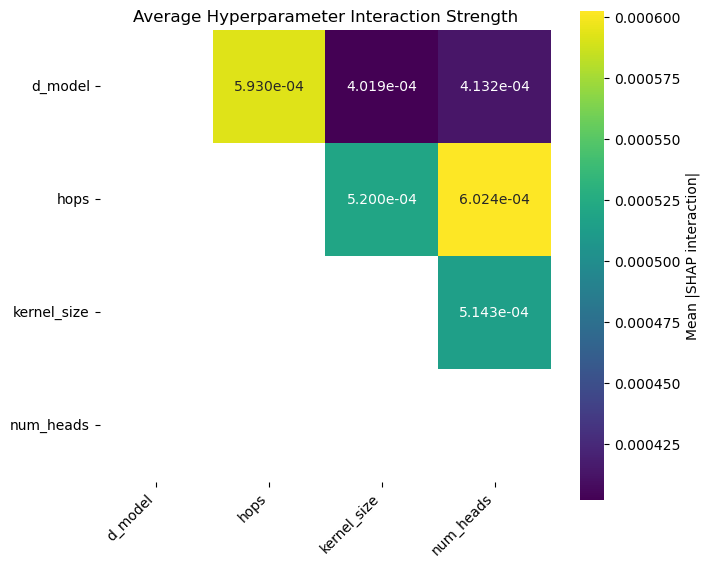

In [14]:
# Make unordered feature-pair labels, then average duplicated directions
interaction_plot_df = interaction_all.copy()

interaction_plot_df["f_low"] = interaction_plot_df[["feature_1", "feature_2"]].min(axis=1)
interaction_plot_df["f_high"] = interaction_plot_df[["feature_1", "feature_2"]].max(axis=1)

pair_avg = (
    interaction_plot_df
    .groupby(["f_low", "f_high"], as_index=False)["interaction_strength"]
    .mean()
)

# Get full feature list
features = sorted(set(pair_avg["f_low"]).union(pair_avg["f_high"]))

# Build symmetric matrix
interaction_matrix = pd.DataFrame(0.0, index=features, columns=features)

for _, row in pair_avg.iterrows():
    f1 = row["f_low"]
    f2 = row["f_high"]
    val = row["interaction_strength"]
    interaction_matrix.loc[f1, f2] = val
    interaction_matrix.loc[f2, f1] = val

# Optional: blank diagonal if you only want pairwise interactions
np.fill_diagonal(interaction_matrix.values, np.nan)

mask = np.tril(np.ones_like(interaction_matrix, dtype=bool))

plt.figure(figsize=(1.8 * len(features), 1.5 * len(features)))
sns.heatmap(
    interaction_matrix,
    mask=mask,
    cmap="viridis",
    annot=True,
    fmt=".3e",
    cbar_kws={"label": "Mean |SHAP interaction|"},
    square=True
)
plt.title("Average Hyperparameter Interaction Strength")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()